### 1.- Librerias

In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

# 2.- Cargar dataset

In [3]:
data = pd.read_csv("municipios_occidente_riesgo_CENAPRED.csv")

# 3.- Preprocesamiento

In [5]:
# Mapeo de valores categóricos a números para poder calcular fitness
map_sismo = {"A":1, "B":2, "C":3, "D":4}
map_inundacion = {"Muy bajo":1, "Bajo":2, "Medio":3, "Alto":4, "Muy alto":5}
map_vulnerabilidad = {"Muy bajo":1, "Bajo":2, "Medio":3, "Alto":4, "Muy alto":5}
map_arm = {"Sí":0, "No":1}  # Preferencia extra si no tiene ARM

data["sismo"] = data["zona_sismica_CFE"].map(map_sismo)
data["inundacion"] = data["grado_peligro_inundacion_CENAPRED"].map(map_inundacion)
data["vulnerabilidad"] = data["grado_vulnerabilidad_social_CENAPRED"].map(map_vulnerabilidad)
data["sin_ARM"] = data["tiene_ARM"].map(map_arm)

# Supongamos que cada intervención cuesta lo mismo (ej. 50,000 MXN)
costo_por_municipio = 50000
presupuesto_total = 10000000

# 4.- Representación del cromosoma

In [6]:
# Cada cromosoma es un vector binario de longitud N (municipios)
# 1 = municipio recibe intervención, 0 = no recibe
num_municipios = len(data)

def generar_individuo():
    return np.random.randint(0, 2, num_municipios)

# 5.- Función de fitness

In [7]:
# Fórmula propuesta:
# fitness = Σ (sismo*2 + inundacion*1.5 + vulnerabilidad*2 + sin_ARM*3) * gen
# Penalización si excede presupuesto
def calcular_fitness(individuo):
    seleccionados = np.where(individuo == 1)[0]
    costo = len(seleccionados) * costo_por_municipio
    
    # Suma ponderada de riesgos
    riesgo_total = 0
    for idx in seleccionados:
        riesgo_total += (data.iloc[idx]["sismo"]*2 +
                         data.iloc[idx]["inundacion"]*1.5 +
                         data.iloc[idx]["vulnerabilidad"]*2 +
                         data.iloc[idx]["sin_ARM"]*3)
    
    # Penalización si excede presupuesto
    if costo > presupuesto_total:
        riesgo_total -= (costo - presupuesto_total) / 10000  # penalización proporcional
    
    return riesgo_total

# 6.- Operadores genéticos

In [8]:
def seleccion_torneo(poblacion, k=3):
    # Selección por torneo
    candidatos = random.sample(poblacion, k)
    candidatos.sort(key=lambda x: x[1], reverse=True)
    return candidatos[0][0]  # devuelve el cromosoma

def cruzamiento(padre1, padre2):
    # Cruzamiento de un punto
    punto = random.randint(1, num_municipios-1)
    hijo1 = np.concatenate([padre1[:punto], padre2[punto:]])
    hijo2 = np.concatenate([padre2[:punto], padre1[punto:]])
    return hijo1, hijo2

def mutacion(individuo, tasa=0.01):
    # Mutación bit-flip
    for i in range(num_municipios):
        if random.random() < tasa:
            individuo[i] = 1 - individuo[i]
    return individuo

# 7.- Algoritmo Genético

In [9]:
def algoritmo_genetico(num_generaciones=50, tam_poblacion=30, tasa_mutacion=0.01):
    # Inicializar población
    poblacion = []
    for _ in range(tam_poblacion):
        ind = generar_individuo()
        poblacion.append((ind, calcular_fitness(ind)))
    
    fitness_promedio = []
    
    for gen in range(num_generaciones):
        nueva_poblacion = []
        
        # Elitismo: conservar el mejor
        poblacion.sort(key=lambda x: x[1], reverse=True)
        nueva_poblacion.append(poblacion[0])
        
        # Generar nueva población
        while len(nueva_poblacion) < tam_poblacion:
            padre1 = seleccion_torneo(poblacion)
            padre2 = seleccion_torneo(poblacion)
            hijo1, hijo2 = cruzamiento(padre1, padre2)
            hijo1 = mutacion(hijo1, tasa_mutacion)
            hijo2 = mutacion(hijo2, tasa_mutacion)
            nueva_poblacion.append((hijo1, calcular_fitness(hijo1)))
            nueva_poblacion.append((hijo2, calcular_fitness(hijo2)))
        
        poblacion = nueva_poblacion[:tam_poblacion]
        fitness_promedio.append(np.mean([fit for _, fit in poblacion]))
    
    # Mejor solución encontrada
    poblacion.sort(key=lambda x: x[1], reverse=True)
    mejor_individuo, mejor_fitness = poblacion[0]
    return mejor_individuo, mejor_fitness, fitness_promedio

# 8.- Experimentos

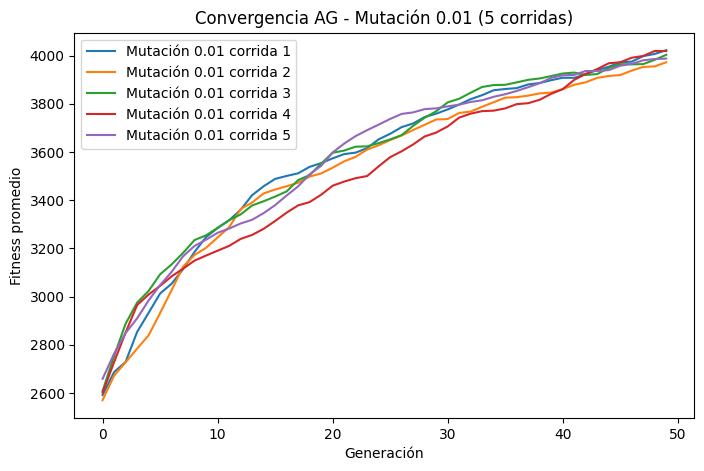

In [12]:
resultados_001 = []
plt.figure(figsize=(8,5))

for corrida in range(5):
    mejor_individuo, mejor_fitness, fitness_promedio = algoritmo_genetico(tasa_mutacion=0.01)
    seleccionados = np.where(mejor_individuo == 1)[0]
    costo = len(seleccionados) * costo_por_municipio
    
    resultados_001.append({
        "corrida": corrida+1,
        "fitness": mejor_fitness,
        "presupuesto": costo
    })
    
    # Graficar convergencia de cada corrida
    plt.plot(fitness_promedio, label=f"Mutación 0.01 corrida {corrida+1}")

plt.xlabel("Generación")
plt.ylabel("Fitness promedio")
plt.legend()
plt.title("Convergencia AG - Mutación 0.01 (5 corridas)")
plt.show()



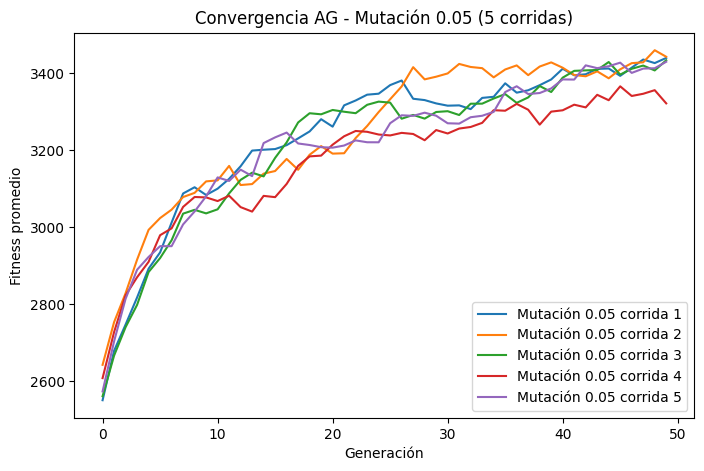

In [13]:
resultados_005 = []
plt.figure(figsize=(8,5))

for corrida in range(5):
    mejor_individuo, mejor_fitness, fitness_promedio = algoritmo_genetico(tasa_mutacion=0.05)
    seleccionados = np.where(mejor_individuo == 1)[0]
    costo = len(seleccionados) * costo_por_municipio
    
    resultados_005.append({
        "corrida": corrida+1,
        "fitness": mejor_fitness,
        "presupuesto": costo
    })
    
    # Graficar convergencia de cada corrida
    plt.plot(fitness_promedio, label=f"Mutación 0.05 corrida {corrida+1}")

plt.xlabel("Generación")
plt.ylabel("Fitness promedio")
plt.legend()
plt.title("Convergencia AG - Mutación 0.05 (5 corridas)")
plt.show()


In [14]:
tabla_001 = pd.DataFrame(resultados_001)
tabla_005 = pd.DataFrame(resultados_005)

print("Resultados con tasa de mutación 0.01")
display(tabla_001)

print("Resultados con tasa de mutación 0.05")
display(tabla_005)

# Comparativa de promedios y mejores fitness
comparativa = pd.DataFrame({
    "Mutación 0.01": [tabla_001["fitness"].mean(), tabla_001["fitness"].max()],
    "Mutación 0.05": [tabla_005["fitness"].mean(), tabla_005["fitness"].max()]
}, index=["Fitness promedio","Mejor fitness"])
display(comparativa)


Resultados con tasa de mutación 0.01


,corrida,fitness,presupuesto
0,1,4102.0,11300000
1,2,4036.5,11100000
2,3,4063.5,11300000
3,4,4087.0,11250000
4,5,4038.5,11100000


Resultados con tasa de mutación 0.05


,corrida,fitness,presupuesto
0,1,3697.5,9950000
1,2,3709.5,9950000
2,3,3656.0,9700000
3,4,3571.0,9650000
4,5,3688.5,9900000


,Mutación 0.01,Mutación 0.05
Fitness promedio,4065.5,3664.5
Mejor fitness,4102.0,3709.5


# 9.- Guardar Minicipios Seleccionados

In [17]:
#Mejor_individuo de una corrida
seleccionados = np.where(mejor_individuo == 1)[0]
municipios_seleccionados = data.iloc[seleccionados].copy()

# Calcular beneficio y costo por municipio
municipios_seleccionados["beneficio"] = (
    municipios_seleccionados["sismo"]*2 +
    municipios_seleccionados["inundacion"]*1.5 +
    municipios_seleccionados["vulnerabilidad"]*2 +
    municipios_seleccionados["sin_ARM"]*3
)
municipios_seleccionados["costo"] = costo_por_municipio

# Guardar en CSV
municipios_seleccionados.to_csv("municipios_seleccionados_mutacion001_corrida1.csv", index=False)

